# Fashion MNIST Classification using Deep Learning

This project implements and compares:
- Artificial Neural Networks (ANN)
- Convolutional Neural Networks (CNN)

Key Highlights:
- Hyperparameter tuning using Optuna
- Transfer learning using VGG16
- Performance comparison using multiple metrics

### Importing Libraries

In this section, we import all the necessary libraries required for:
- Data handling (Pandas, NumPy)
- Model building (PyTorch)
- Evaluation metrics (Scikit-learn)
- Image processing (Torchvision, PIL)
- Visualization (Matplotlib)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
from torchvision.transforms import transforms
from PIL import Image
import torchvision.models as models

### Reproducibility

To ensure consistent results across multiple runs, we set a random seed.
This helps in debugging and comparing model performance reliably.

In [ ]:
torch.manual_seed(42)

### Device Configuration

We check whether a GPU is available and use it for faster computation.
If GPU is not available, the model will run on CPU.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Loading Dataset

We load the Fashion MNIST dataset from a CSV file.
- Total samples: 60,000
- Each image: 28x28 pixels (flattened to 784 features)
- First column: Label
- Remaining columns: Pixel values

In [ ]:
df = pd.read_csv('fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(60000, 785)

### Visualizing Sample Images

We display the first 16 images from the dataset to:
- Understand data distribution
- Verify labels visually

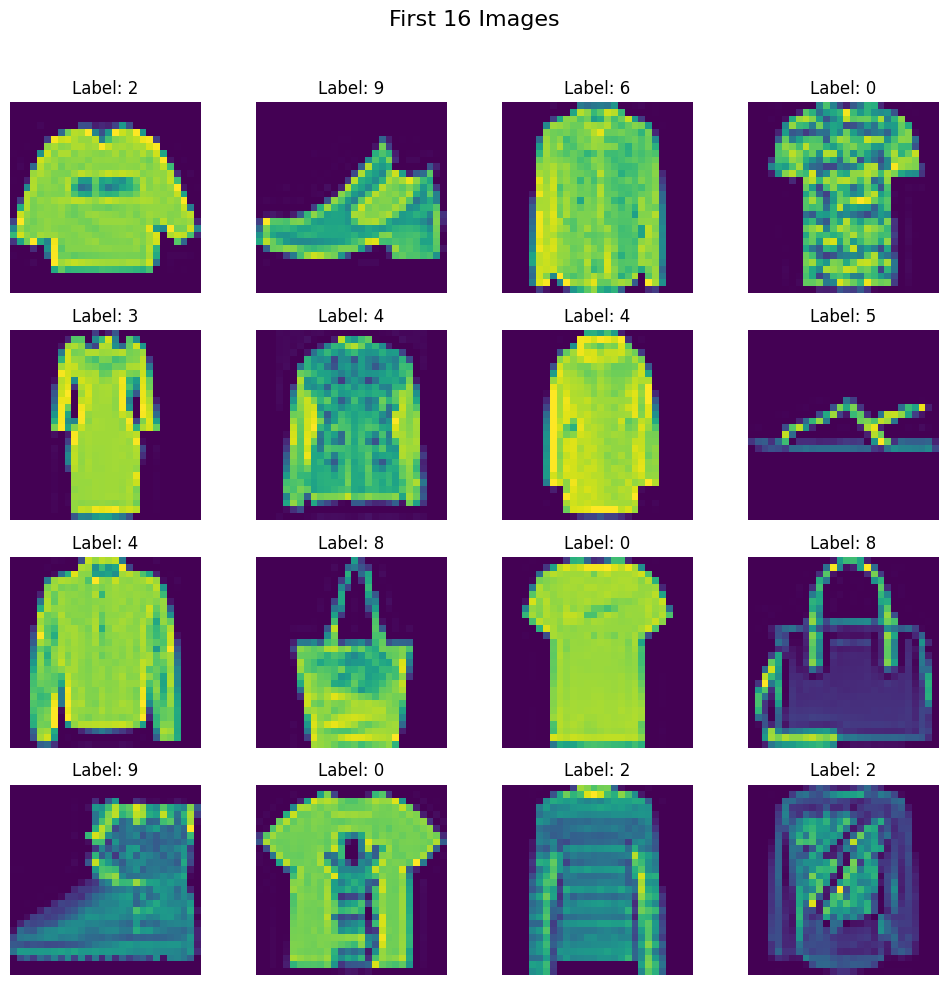

In [ ]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

### Splitting the Dataset

We divide the dataset into:
- Training set (80%)
- Testing set (20%)



In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

Two approaches:
1. Simple Train-Test **Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

2. K-Fold Cross Validation

In [ ]:

# K-Fold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# take first fold only (like train_test_split equivalent)
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    break   # take only first split

## Working on Artificial Neural Network (ANN)

### Feature Scaling

Pixel values are normalized to the range [0,1] by dividing by 255.

Note: This step is required for ANN but not for CNN.

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

### Creating Custom Dataset

We define a PyTorch Dataset class to:
- Convert features and labels into tensors
- Enable efficient data loading using DataLoader

In [ ]:
class CustomDataset_ann(Dataset):

  def __init__(self, features, labels):

    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):

    return len(self.features)

  def __getitem__(self, index):

    return self.features[index], self.labels[index]

In [ ]:
train_dataset = CustomDataset_ann(X_train, y_train)

In [ ]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0157, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.2431, 0.2392, 0.0824, 0.1137, 0.0902,
         0.2000, 0.5333, 0.2392, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [ ]:
test_dataset = CustomDataset_ann(X_test, y_test)

In [ ]:
test_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.1804, 0.0000, 0.0824, 0.2667, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0980, 0.7333, 0.7412, 0.0000, 0.4667, 0.6784, 0.9373, 0.4392, 0.0000,
         0.7412, 0.4902, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0549, 0.8588, 0.8784, 0.8275, 0.3608, 0.2039, 0.8902, 0.8784, 0.4980,
         0.3608, 0.7686, 0.9294, 0.5333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.4157, 0.9333, 0.7922, 0.8039, 0.8784, 0.8824, 0.8510, 0.8549,
         0.8706, 0.8902, 0.7922, 0.8078, 0.8549, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

### Building ANN Model

We create a flexible ANN model with:
- Variable hidden layers
- Batch Normalization
- ReLU activation
- Dropout for regularization

This dynamic architecture allows hyperparameter tuning.

In [ ]:
class My_ANN(nn.Module):
  def __init__(self,input_dim,output_dim,num_hidden_layers,neurons_per_layer,dropout_rate):
    super().__init__()

    # dynamic code
    layers = []

    for i in range(num_hidden_layers):

      layers.append(nn.Linear(input_dim, neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer, output_dim))


    self.model = nn.Sequential(*layers)

  def forward(self,x):

    return self.model(x)

In [ ]:
# objective function

def objective(trial):

  # next hyperparameter values from the search space
  num_hidden_layers = trial.suggest_int('num_hidden_layers', 1, 5)
  neurons_per_layer = trial.suggest_int(
    'neuron_per_layer',
    8, 128,
    step=8
  )
  epochs = trial.suggest_int(
    'epochs',
    10, 50,
    step=10
  )

  learning_rate = trial.suggest_float(
      "learning_rate",1e-5,1e-1,log=True
  )

  dropout_rate = trial.suggest_float(
      "dropout_rate",0.1,0.5,step=0.1
  )

  batch_size = trial.suggest_categorical(
      "batch_size",[16,32,64,128]
  )

  optimizer_name = trial.suggest_categorical(
      "optimizer",["Adam","SGD","RMSprop"]
  )

  weight_decay = trial.suggest_float(
      "weight_decay",1e-5,1e-3,log=True
  )

  # create train and test loader
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

  # model init
  input_dim = 784
  output_dim = 10

  model = My_ANN(input_dim,output_dim,num_hidden_layers,neurons_per_layer,dropout_rate)
  model.to(device)


  # optimizer selection
  criterion = nn.CrossEntropyLoss()
  if optimizer_name == "Adam":
    optimizer = optim.Adam(model.parameters(), lr= 0.1, weight_decay= weight_decay)
  elif optimizer_name == "RMSprop":
    optimizer = optim.RMSprop(model.parameters(), lr= 0.1, weight_decay= weight_decay)
  else :
    optimizer = optim.SGD(model.parameters(), lr= 0.1, weight_decay= weight_decay)

  # training loop

  for epoch in range(epochs):

    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:

      # move data to GPU
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      # forward pass
      outputs = model(batch_features)

      # calculate loss
      loss = criterion(outputs, batch_labels)

      # back pass
      optimizer.zero_grad()
      loss.backward()

      # update grads
      optimizer.step()

    # evaluation

    # set model to eval mode
    model.eval()

    # evaluation code
    total = 0
    correct = 0

    with torch.no_grad():

      for batch_features, batch_labels in test_loader:

        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = model(batch_features)

        _, predicted = torch.max(outputs, 1)

        total = total + batch_labels.shape[0]

        correct = correct + (predicted == batch_labels).sum().item()

    accuracy = (correct/total)
  return accuracy

### Evaluation Metrics

We evaluate model performance using:
- Accuracy
- Precision
- Recall
- F1 Score

These metrics provide a complete understanding of model performance.

NOTE : We will call evaluate_model for both ANN and CNN models evaluation.

In [ ]:
def evaluate_model(model, data_loader):

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_features, batch_labels in data_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())

    accuracy = (np.array(all_preds) == np.array(all_labels)).mean()
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

### Confusion matrix

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, dataloader, device, class_names=None, title="Confusion Matrix"):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(title)
    plt.show()

    return cm  # optional (useful if you want accuracy etc.)

### Hyperparameter Tuning using Optuna

We use Optuna to automatically search for the best:
- Number of layers
- Neurons per layer
- Learning rate
- Dropout rate
- Optimizer type
- Batch size

Objective: Maximize model accuracy

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.2 MB/s eta 0:00:00


In [ ]:
import optuna

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

[I 2026-03-31 05:41:59,848] A new study created in memory with name: no-name-054ff993-145f-44a3-a1e8-68fbeb09719f
[I 2026-03-31 05:43:36,724] Trial 0 finished with value: 0.8805833333333334 and parameters: {'num_hidden_layers': 4, 'neuron_per_layer': 112, 'epochs': 40, 'learning_rate': 0.011559856473941617, 'dropout_rate': 0.5, 'batch_size': 128, 'optimizer': 'SGD', 'weight_decay': 4.1684878876987926e-05}. Best is trial 0 with value: 0.8805833333333334.
[I 2026-03-31 06:04:22,033] Trial 1 finished with value: 0.1 and parameters: {'num_hidden_layers': 4, 'neuron_per_layer': 128, 'epochs': 40, 'learning_rate': 0.0021943348209859043, 'dropout_rate': 0.1, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.00018198849819496337}. Best is trial 0 with value: 0.8805833333333334.
[I 2026-03-31 06:05:58,369] Trial 2 finished with value: 0.8686666666666667 and parameters: {'num_hidden_layers': 3, 'neuron_per_layer': 40, 'epochs': 30, 'learning_rate': 0.0004079728731495979, 'dropout_rate': 0

In [ ]:
study.best_value

0.89025

In [ ]:
study.best_params

{'num_hidden_layers': 5,
 'neuron_per_layer': 104,
 'epochs': 40,
 'learning_rate': 0.0009505741229216951,
 'dropout_rate': 0.30000000000000004,
 'batch_size': 64,
 'optimizer': 'SGD',
 'weight_decay': 6.725238672704062e-05}

### Training Final ANN Model

Using the best hyperparameters obtained from Optuna:
- Train the final model
- Evaluate performance on test data

In [ ]:
best_params = study.best_params

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'], shuffle=False)

model = My_ANN(
    784,
    10,
    best_params['num_hidden_layers'],
    best_params['neuron_per_layer'],
    best_params['dropout_rate']
).to(device)

In [ ]:
if best_params['optimizer'] == "Adam":
    optimizer = optim.Adam(model.parameters(), lr=best_params['learning_rate'], weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == "RMSprop":
    optimizer = optim.RMSprop(model.parameters(), lr=best_params['learning_rate'], weight_decay=best_params['weight_decay'])
else:
    optimizer = optim.SGD(model.parameters(), lr=best_params['learning_rate'], weight_decay=best_params['weight_decay'])

criterion = nn.CrossEntropyLoss()

In [ ]:
for epoch in range(best_params['epochs']):
    model.train()
    for batch_features, batch_labels in train_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

In [ ]:
evaluate_model(model, test_loader)

Accuracy: 0.8508
Precision: 0.8499
Recall: 0.8508
F1 Score: 0.8481


### Confusion matrix for ANN

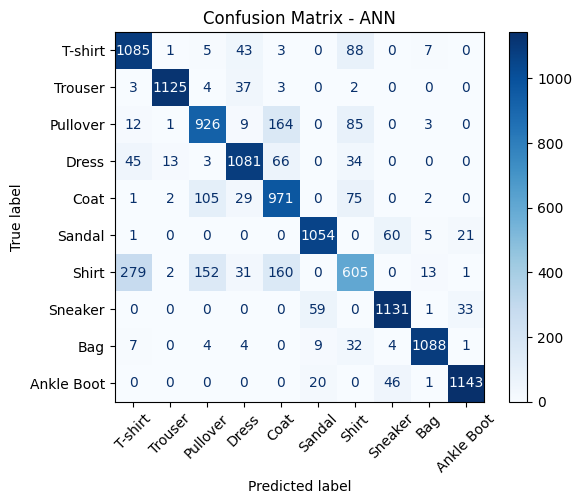

array([[1085,    1,    5,   43,    3,    0,   88,    0,    7,    0],
       [   3, 1125,    4,   37,    3,    0,    2,    0,    0,    0],
       [  12,    1,  926,    9,  164,    0,   85,    0,    3,    0],
       [  45,   13,    3, 1081,   66,    0,   34,    0,    0,    0],
       [   1,    2,  105,   29,  971,    0,   75,    0,    2,    0],
       [   1,    0,    0,    0,    0, 1054,    0,   60,    5,   21],
       [ 279,    2,  152,   31,  160,    0,  605,    0,   13,    1],
       [   0,    0,    0,    0,    0,   59,    0, 1131,    1,   33],
       [   7,    0,    4,    4,    0,    9,   32,    4, 1088,    1],
       [   0,    0,    0,    0,    0,   20,    0,   46,    1, 1143]])

In [ ]:
class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

plot_confusion_matrix(model, test_loader, device, class_names,
                      title="Confusion Matrix - ANN")

# Working on Convolutional Neural Network (CNN)

---



### Preparing Data for CNN

Since ANN used normalized data:
- We revert pixel values back to [0–255]

This is required because CNN uses image transformations.

In [ ]:
X_train = (X_train * 255).astype('uint8')
X_test  = (X_test * 255).astype('uint8')

### Applying Transformations

We apply:
- Resize (256x256)
- Center Crop (224x224)
- Normalization (ImageNet standards)

This prepares images for pretrained models like VGG16.

In [ ]:
custom_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]) # taken from pytorch docs
])

In [ ]:
X_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

### CNN Dataset Preparation

Steps:
- Reshape 784 → 28x28 image
- Convert grayscale → 3-channel image
- Convert to PIL Image
- Apply transformations



In [ ]:
class CustomDataset_cnn(Dataset):

  def __init__(self,features,labels,transform):
    self.features = features
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):

    # resize to (28,28)
    image = self.features[index].reshape(28,28)

    # change datatypes to np.uint8
    image = image.astype(np.uint8)

    #change black&white to colour image
    image = np.stack([image]*3, axis=-1) # values of 1 channel copied to other 2 channels as well
    # since above code gives. (Height H, width W, channel c)-> (c,h,w)

    # convert array to PIL image
    image = Image.fromarray(image)

    # apply transforms
    image = self.transform(image)

    # return
    return image, torch.tensor(self.labels[index],dtype=torch.long)


### Data Loading

We use DataLoader to:
- Load data in batches
- Shuffle training data
- Improve training efficiency

In [ ]:
train_dataset = CustomDataset_cnn(X_train, y_train, transform = custom_transform)

In [ ]:
test_dataset = CustomDataset_cnn(X_test, y_test, transform = custom_transform)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory = True)

In [ ]:
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory = True)

### Transfer Learning using VGG16

We use a pretrained VGG16 model:
- Trained on ImageNet
- Helps in faster convergence
- Improves performance

In [ ]:
vgg16 = models.vgg16(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 92.7MB/s]


In [ ]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
vgg16.features

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [ ]:
vgg16.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

### Freezing Layers

We freeze convolutional layers to:
- Preserve learned features
- Train only the classifier



In [ ]:
for param in vgg16.features.parameters():
  param.requires_grad = False

### Custom Classifier

We replace the original classifier with:
- Fully connected layers
- Dropout for regularization
- Output layer (10 classes)

In [ ]:
vgg16.classifier = nn.Sequential(
    nn.Linear(25088,1024),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(1024,512),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(512,10)
)

In [ ]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### Training the CNN

We train the model using:
- Adam optimizer
- CrossEntropy Loss
- Reduced learning rate for stability

In [ ]:
vgg16 = vgg16.to(device)

In [ ]:
epochs = 10 # as 100 epochs will take very long time
learning_rate = 0.0001 # recommended to keep it low (slow learning rate)

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer = optim.Adam(vgg16.classifier.parameters(), lr= learning_rate) # adam performs better

In [ ]:
for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move data to GPU
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    # forward pass
    outputs = vgg16(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 1 , Loss: 0.36495137070988615
Epoch: 2 , Loss: 0.21795710337286195
Epoch: 3 , Loss: 0.16665386125724763
Epoch: 4 , Loss: 0.13167894690157847
Epoch: 5 , Loss: 0.10553637962446859
Epoch: 6 , Loss: 0.08136923791035466
Epoch: 7 , Loss: 0.06599585174489767
Epoch: 8 , Loss: 0.05698340501729399
Epoch: 9 , Loss: 0.04589581859134099
Epoch: 10 , Loss: 0.041611869696326416


### CNN Evaluation

We evaluate CNN performance using the same metrics:
- Accuracy
- Precision
- Recall
- F1 Score

In [ ]:
evaluate_model(vgg16,test_loader)

Accuracy: 0.9261
Precision: 0.9266
Recall: 0.9261
F1 Score: 0.9255


### Confusion matrix

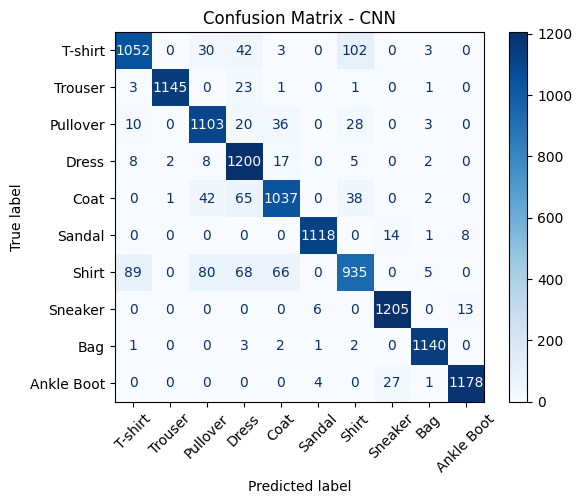

array([[1052,    0,   30,   42,    3,    0,  102,    0,    3,    0],
       [   3, 1145,    0,   23,    1,    0,    1,    0,    1,    0],
       [  10,    0, 1103,   20,   36,    0,   28,    0,    3,    0],
       [   8,    2,    8, 1200,   17,    0,    5,    0,    2,    0],
       [   0,    1,   42,   65, 1037,    0,   38,    0,    2,    0],
       [   0,    0,    0,    0,    0, 1118,    0,   14,    1,    8],
       [  89,    0,   80,   68,   66,    0,  935,    0,    5,    0],
       [   0,    0,    0,    0,    0,    6,    0, 1205,    0,   13],
       [   1,    0,    0,    3,    2,    1,    2,    0, 1140,    0],
       [   0,    0,    0,    0,    0,    4,    0,   27,    1, 1178]])

In [ ]:
class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

plot_confusion_matrix(vgg16, test_loader, device, class_names,
                      title="Confusion Matrix - CNN")

## Conclusion

- ANN provides decent performance with proper tuning.
- CNN significantly improves accuracy due to spatial feature extraction.
- Transfer learning (VGG16) boosts performance even on small images.

 CNN outperforms ANN for image classification tasks.